In [33]:
from huggingface_hub import login, whoami

login() 

print("WHOAMI:", whoami())

WHOAMI: {'type': 'user', 'id': '68f73ee01ad84a2703897fc0', 'name': 'BZakaria', 'fullname': 'Bougayou', 'isPro': False, 'avatarUrl': '/avatars/fce140a2f737760bbffe1def74364805.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'jupyter-access', 'role': 'fineGrained', 'createdAt': '2025-10-23T08:06:32.925Z', 'fineGrained': {'canReadGatedRepos': True, 'global': [], 'scoped': [{'entity': {'_id': '68f73ee01ad84a2703897fc0', 'type': 'user', 'name': 'BZakaria'}, 'permissions': ['repo.content.read']}]}}}}


In [34]:
import os

# Route caches to your RAID (adjust to your paths if needed)
os.environ.setdefault("HF_HOME", "/info/raid-etu/m2/s2506967/.cache/huggingface")
os.environ.setdefault("HF_DATASETS_CACHE", "/info/raid-etu/m2/s2506967/.cache/huggingface/datasets")
os.environ.setdefault("HF_HUB_CACHE", "/info/raid-etu/m2/s2506967/.cache/huggingface/hub")

# Avoid ipywidgets/tqdm crashes in remote Jupyter
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "1"

# Disable Xet backend (sometimes flaky on campus networks)
os.environ["HF_HUB_DISABLE_XET"] = "1"

# Optional: quiet telemetry & logs
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

from datasets.utils.logging import set_verbosity_warning
set_verbosity_warning()

In [35]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, Audio, concatenate_datasets, DatasetDict
from jiwer import wer, mer, wil, wip, cer
from huggingface_hub import snapshot_download
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

In [36]:
import os
for k in ["HF_HUB_DISABLE_PROGRESS_BARS", "TQDM_DISABLE"]:
    if k in os.environ:
        del os.environ[k]

In [37]:
LANGUAGE   = "french"
TASK       = "transcribe"
TARGET_SR  = 16000

MODEL_NAME = "openai/whisper-tiny"

# Subset sizes
N_TRAIN = 8000
N_VAL   = 3000
N_TEST  = 3000

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [38]:
cv = load_dataset("mozilla-foundation/common_voice_12_0", "fr")
print(cv)

Using the latest cached version of the module from /info/raid-etu/m2/s2506967/.huggingface/modules/datasets_modules/datasets/mozilla-foundation--common_voice_12_0/d0bcb8d624bede15a5a1232d33fcd77675146c0bb96a6e7b864486eab769a8d4 (last modified on Tue Oct 21 11:16:14 2025) since it couldn't be found locally at mozilla-foundation/common_voice_12_0, or remotely on the Hugging Face Hub.


DatasetDict({
    train: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment'],
        num_rows: 499535
    })
    validation: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment'],
        num_rows: 16104
    })
    test: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment'],
        num_rows: 16104
    })
    other: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment'],
        num_rows: 34255
    })
    invalidated: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment'],
        num_rows: 58418
    })
})


In [39]:
split_sizes = {name: len(ds) for name, ds in cv.items()}
print("Split sizes:", split_sizes)

Split sizes: {'train': 499535, 'validation': 16104, 'test': 16104, 'other': 34255, 'invalidated': 58418}


In [40]:
def safe_sample(ds, n, seed=SEED):
    n = min(n, len(ds))
    if n <= 0:
        return ds.select([])
    return ds.shuffle(seed=seed).select(range(n))

train_ds = safe_sample(cv["train"], N_TRAIN)
val_ds   = safe_sample(cv["validation"], N_VAL)
test_ds  = safe_sample(cv["test"], N_TEST)

In [41]:
# Cast audio to 16 kHz (Whisper expects 16k input features)
train_ds = train_ds.cast_column("audio", Audio(sampling_rate=TARGET_SR))
val_ds   = val_ds.cast_column("audio", Audio(sampling_rate=TARGET_SR))
test_ds  = test_ds.cast_column("audio", Audio(sampling_rate=TARGET_SR))

print({"train": len(train_ds), "validation": len(val_ds), "test": len(test_ds)})

{'train': 8000, 'validation': 3000, 'test': 3000}


In [42]:
 # Tag each split with a column "_split"
def tag_split(ds, name):
    # non-batched map is fine here; we just add a constant column
    return ds.map(lambda x: {"_split": name})

# Concatenate the three tagged splits
work_all = concatenate_datasets([
    tag_split(train_ds, "train"),
    tag_split(val_ds, "validation"),
    tag_split(test_ds, "test"),
])

In [43]:
# --- Compute durations & light text stats (batched for speed) ---
def add_basic_fields(batch):
    arrs = [a["array"] for a in batch["audio"]]
    srs  = [a["sampling_rate"] for a in batch["audio"]]
    durations = [float(len(a))/float(sr) if (a is not None and sr) else np.nan for a, sr in zip(arrs, srs)]
    sentences = batch["sentence"]
    n_chars = [len(s) if isinstance(s, str) else 0 for s in sentences]
    n_words = [len(s.split()) if isinstance(s, str) else 0 for s in sentences]
    wpm = [60.0*w/d if d and d > 0 else np.nan for w, d in zip(n_words, durations)]
    return {"duration_s": durations, "n_chars": n_chars, "n_words": n_words, "wpm": wpm}

work_all = work_all.map(add_basic_fields, batched=True, batch_size=256)

In [44]:
# --- Pandas view ---
cols_keep = ["_split","sentence","duration_s","n_words","wpm","gender","age","accent","up_votes","down_votes"]
df = work_all.to_pandas()[[c for c in cols_keep if c in work_all.column_names]]

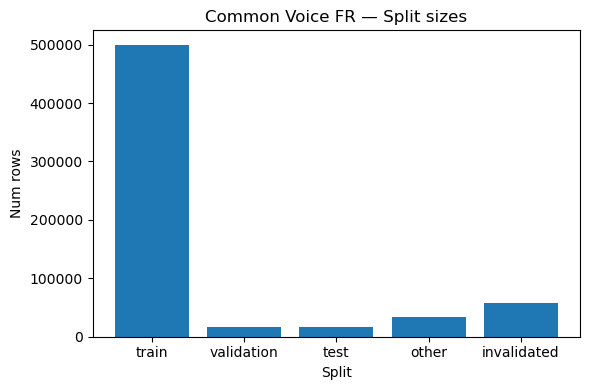

In [45]:
# --- Plots (matplotlib only; no custom colors) ---
plt.figure(figsize=(6,4))
plt.bar(list(split_sizes.keys()), list(split_sizes.values()))
plt.title("Common Voice FR — Split sizes")
plt.xlabel("Split"); plt.ylabel("Num rows"); plt.tight_layout(); plt.show()

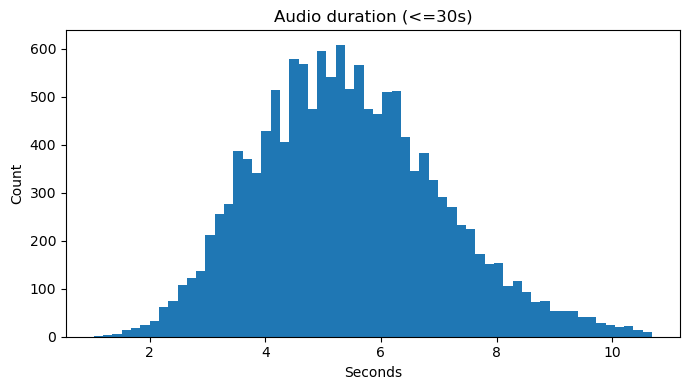

In [46]:
plt.figure(figsize=(7,4))
plt.hist(df["duration_s"].clip(upper=30).dropna(), bins=60)
plt.title("Audio duration (<=30s)"); plt.xlabel("Seconds"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

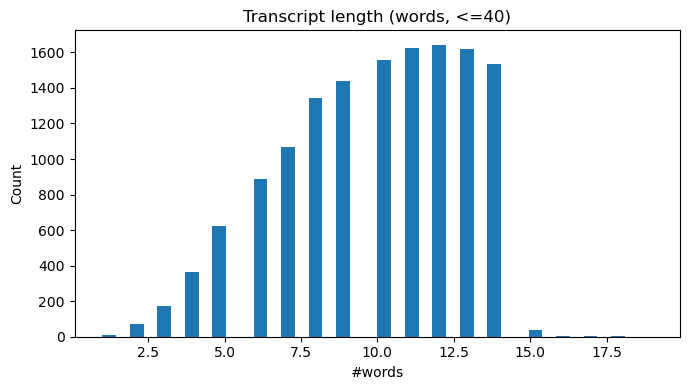

In [47]:
plt.figure(figsize=(7,4))
plt.hist(df["n_words"].clip(upper=40).dropna(), bins=40)
plt.title("Transcript length (words, <=40)"); plt.xlabel("#words"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

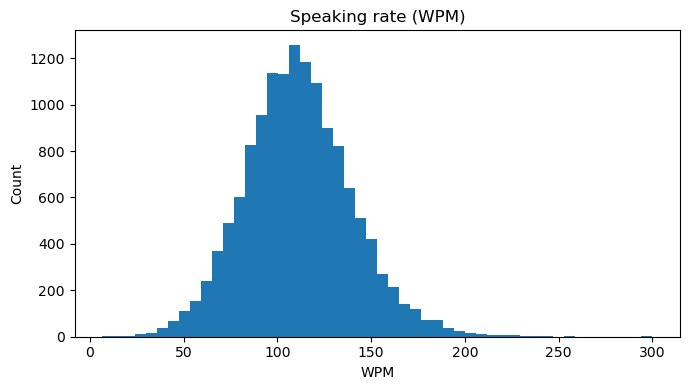

In [48]:
plt.figure(figsize=(7,4))
wpm_cap = df["wpm"].replace([np.inf,-np.inf], np.nan).dropna().clip(upper=300)
plt.hist(wpm_cap, bins=50)
plt.title("Speaking rate (WPM)"); plt.xlabel("WPM"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

In [49]:
from huggingface_hub import snapshot_download
from huggingface_hub.utils import disable_progress_bars
from tqdm.std import tqdm as std_tqdm


disable_progress_bars()

MODEL_NAME = MODEL_NAME 
LANGUAGE   = LANGUAGE
TASK       = TASK

local_repo_path = snapshot_download(
    repo_id=MODEL_NAME,
    allow_patterns=["*.json","*.safetensors","*.model","*.bin","*.txt"],
    # resume_download=True,  # not needed anymore; resume is default
    tqdm_class=std_tqdm,     # force non-notebook progress (or fully disabled by disable_progress_bars)
)


processor = WhisperProcessor.from_pretrained(local_repo_path, language=LANGUAGE, task=TASK)
model = WhisperForConditionalGeneration.from_pretrained(local_repo_path)

# Force French decoding prompts
model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language=LANGUAGE, task=TASK)

# Ensure pad token exists (for loss masking)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token
model.config.pad_token_id = processor.tokenizer.pad_token_id


print("CUDA available / device_count:", torch.cuda.is_available(), "/", torch.cuda.device_count())

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 61756.62it/s]


CUDA available / device_count: True / 1


In [50]:
# Preprocess → input_features & labels (batched; returns NumPy)
def prepare_batch(batch):
    # Audio → input_features (batch)
    audio_arrays = [a["array"] for a in batch["audio"]]
    inputs = processor.feature_extractor(
        audio_arrays,
        sampling_rate=TARGET_SR,
        return_tensors="np"   # NumPy keeps Arrow happy
    )

    # Text → labels (batch)
    texts = [s if isinstance(s, str) else "" for s in batch["sentence"]]
    labels = processor.tokenizer(
        texts,
        return_tensors="np",
        padding="longest"     # keep same length per batch; collator will re-pad across batches
    ).input_ids

    return {
        "input_features": inputs.input_features,  # shape: (B, n_mels, T)
        "labels": labels,                         # shape: (B, L)
    }

# Map with batching
train_proc = train_ds.map(
    prepare_batch,
    batched=True,
    batch_size=32,
    remove_columns=train_ds.column_names,
)
val_proc = val_ds.map(
    prepare_batch,
    batched=True,
    batch_size=32,
    remove_columns=val_ds.column_names,
)
test_proc = test_ds.map(
    prepare_batch,
    batched=True,
    batch_size=32,
    remove_columns=test_ds.column_names,
)

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [51]:
# Collator (unchanged logic; now handles NumPy -> Torch)
class DataCollatorSpeechSeq2SeqWithPadding:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, features):
        # convert to lists of dicts for pad()
        input_features = [{"input_features": f["input_features"]} for f in features]
        label_features = [{"input_ids": f["labels"]} for f in features]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt",
        )
        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt",
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["input_ids"] == self.processor.tokenizer.pad_token_id, -100
        )
        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor)

print("Train example keys:", train_proc[0].keys())

Train example keys: dict_keys(['input_features', 'labels'])


In [52]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

BATCH_SIZE = 8 if torch.cuda.is_available() else 2
GRAD_ACCUM = 2
EPOCHS     = 5
LR         = 1e-7

gen_kwargs = dict(max_new_tokens=128, num_beams=1)

training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper_fr_cv",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    # ✅ Transformers 4.57.1 expects `eval_strategy`
    eval_strategy="epoch",

    save_strategy="epoch",
    learning_rate=LR,
    warmup_ratio=0.05,
    num_train_epochs=EPOCHS,
    fp16=torch.cuda.is_available(),

    predict_with_generate=True,
    generation_max_length=gen_kwargs["max_new_tokens"],
    generation_num_beams=gen_kwargs["num_beams"],

    logging_steps=50,
    logging_strategy="steps",
    report_to=[],

    remove_unused_columns=False,
    disable_tqdm=False,
)

# Use the tokenizer (not the feature_extractor) for full compatibility
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_proc,
    eval_dataset=val_proc,
    data_collator=data_collator,
    tokenizer=processor.tokenizer,
)

print("Transformers:", __import__("transformers").__version__)
train_result = trainer.train()
trainer.save_model()

/tmp/ipykernel_840199/668383892.py:38: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Transformers: 4.57.1


You're using a WhisperTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss
1,2.173700,2.230760
2,1.590600,1.667134
3,1.159400,1.269706
4,1.096900,1.154931
5,0.983100,1.125461


/info/etu/m2/s2506967/anaconda3/envs/covea_env/lib/python3.10/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50358, 50359, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


In [53]:
def decode_batch(pred_ids):
    return processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

In [54]:
def compute_jiwer_metrics(refs, hyps):
    return {
        "WER": wer(refs, hyps),
        "MER": mer(refs, hyps),
        "WIL": wil(refs, hyps),
        "WIP": wip(refs, hyps),
        # CER at corpus-level for stability (concat strings)
        "CER": cer(" ".join(refs), " ".join(hyps)),
    }

In [55]:
@torch.inference_mode()
def predict_texts(dataset, batch_size=None):
    """
    Batched generation for a HF Dataset processed by `prepare_batch`.
    Ensures input features are float32 to match Whisper expectations.
    """
    if batch_size is None:
        batch_size = training_args.per_device_eval_batch_size

    preds, refs = [], []
    device = trainer.args.device
    model.eval()  # just to be explicit

    n = len(dataset)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch = dataset[start:end]  # dict of lists

        # (B, n_mels, n_frames), ensure float32
        feats_np = np.stack(batch["input_features"]).astype(np.float32)
        feats = torch.from_numpy(feats_np).to(device)

        # Generate hypotheses (explicit input_features arg)
        gen = model.generate(input_features=feats, max_new_tokens=128, num_beams=1)
        preds.extend(decode_batch(gen.cpu().numpy()))

        # Decode references
        label_ids_list = batch["labels"]
        pad_id = processor.tokenizer.pad_token_id
        cleaned = []
        for arr in label_ids_list:
            arr = np.asarray(arr)
            if (arr == -100).any():
                arr = np.where(arr == -100, pad_id, arr)
            cleaned.append(arr)
        refs.extend(processor.tokenizer.batch_decode(cleaned, skip_special_tokens=True))

    return refs, preds

In [56]:
# Validation
val_refs, val_hyps = predict_texts(val_proc)
val_metrics = compute_jiwer_metrics(val_refs, val_hyps)
print("Validation:", val_metrics)

Validation: {'WER': 0.6097936556821681, 'MER': 0.583363341735686, 'WIL': 0.7893281824673981, 'WIP': 0.21067181753260195, 'CER': 0.3341466553695342}


In [57]:
# Test
test_refs, test_hyps = predict_texts(test_proc)
test_metrics = compute_jiwer_metrics(test_refs, test_hyps)
print("Test:", test_metrics)

Test: {'WER': 0.6418099176378114, 'MER': 0.6105331599479844, 'WIL': 0.8121328409586881, 'WIP': 0.18786715904131193, 'CER': 0.3619077894578037}


In [58]:
# Save metrics
metrics_df = pd.DataFrame([
    {"split": "validation", **val_metrics},
    {"split": "test", **test_metrics},
])
metrics_df.to_csv("whisper_cv_fr_metrics.csv", index=False)
metrics_df

,split,WER,MER,WIL,WIP,CER
0,validation,0.609794,0.583363,0.789328,0.210672,0.334147
1,test,0.641810,0.610533,0.812133,0.187867,0.361908
